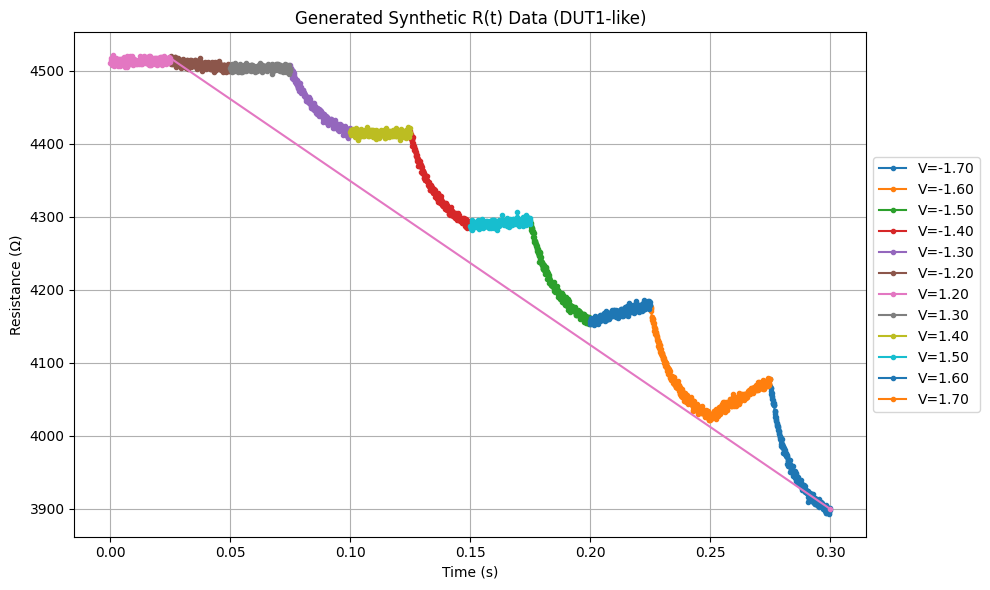

Using device: cpu


c:\Users\ARAVIND KRISHNAN R S\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training...
Epoch 0/24999: Total Loss=4.0383e+01, Data Loss=3.5279e-02, Physics Loss=5.1045e+00, Mean Residual=1.1695e+04, LR=1.0e-03
Epoch 100/24999: Total Loss=6.0568e-01, Data Loss=5.1090e-04, Physics Loss=7.2139e-02, Mean Residual=2.2177e+03, LR=1.0e-03
Epoch 200/24999: Total Loss=5.4677e-01, Data Loss=4.5197e-04, Physics Loss=7.4122e-02, Mean Residual=2.2353e+03, LR=1.0e-03
Epoch 300/24999: Total Loss=5.5755e-01, Data Loss=4.6501e-04, Physics Loss=7.0004e-02, Mean Residual=2.1455e+03, LR=1.0e-03
Epoch 400/24999: Total Loss=5.2536e-01, Data Loss=4.3270e-04, Physics Loss=6.9149e-02, Mean Residual=2.1248e+03, LR=1.0e-03
Epoch 500/24999: Total Loss=4.7337e-01, Data Loss=3.8200e-04, Physics Loss=7.1194e-02, Mean Residual=2.1287e+03, LR=1.0e-03
Epoch 600/24999: Total Loss=4.4768e-01, Data Loss=3.5986e-04, Physics Loss=6.3917e-02, Mean Residual=1.9904e+03, LR=1.0e-03
Epoch 700/24999: Total Loss=4.5326e-01, Data Loss=3.6743e-04, Physics Loss=6.3155e-02, Mean Residual=1.9371e+03, 

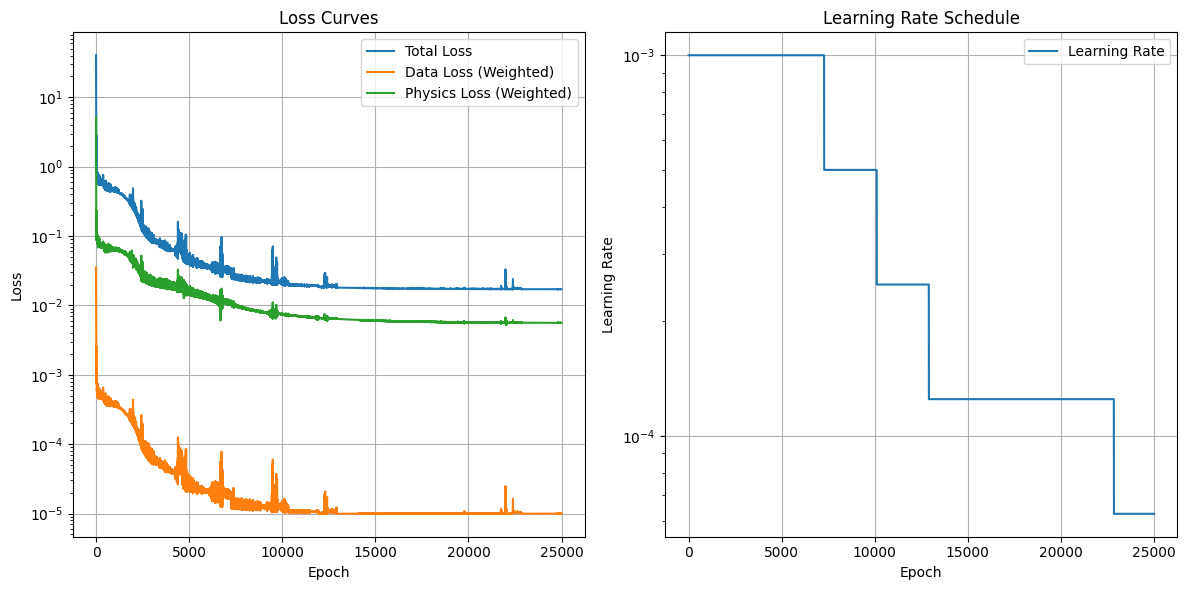

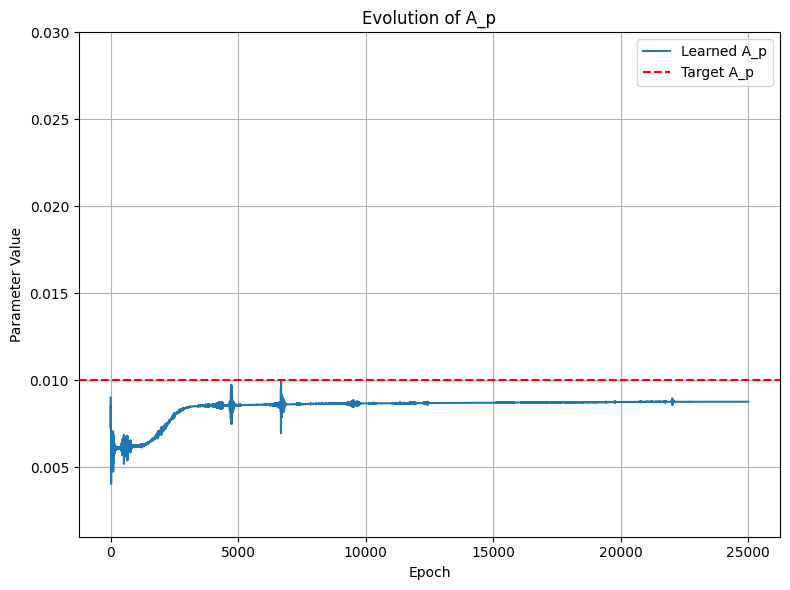

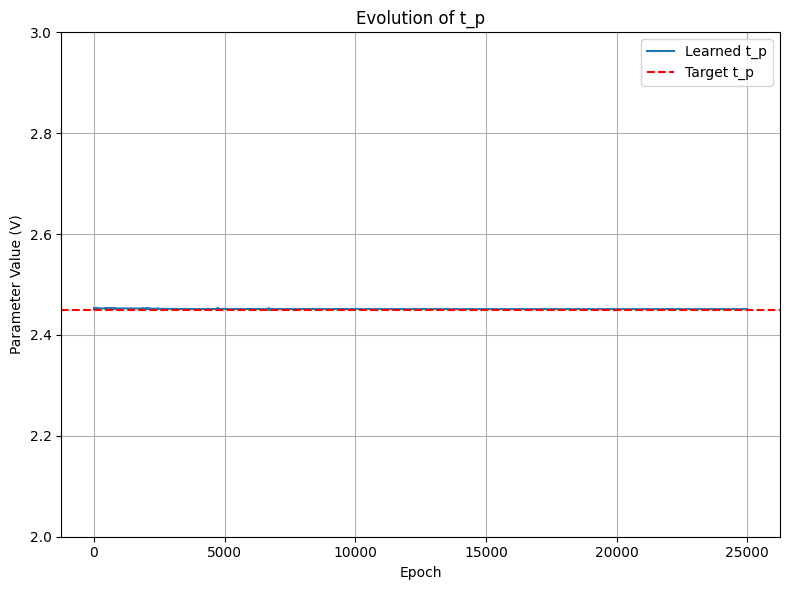

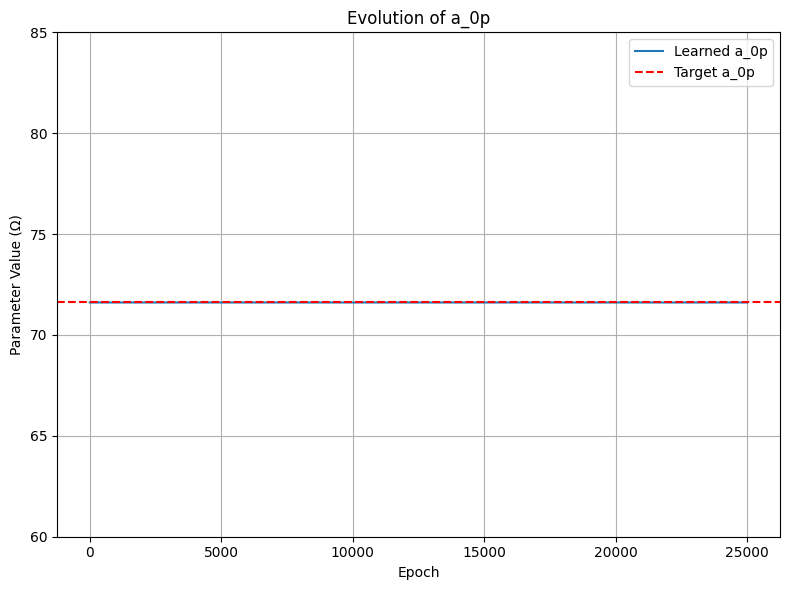

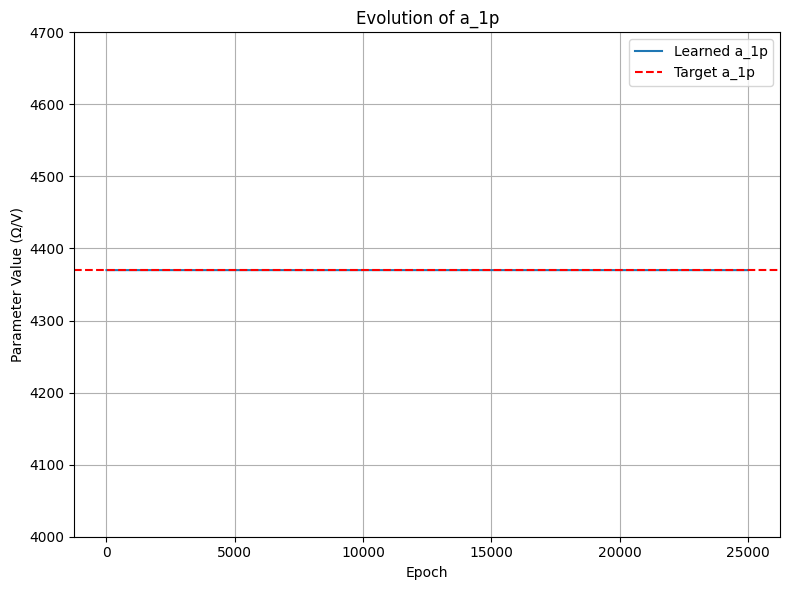

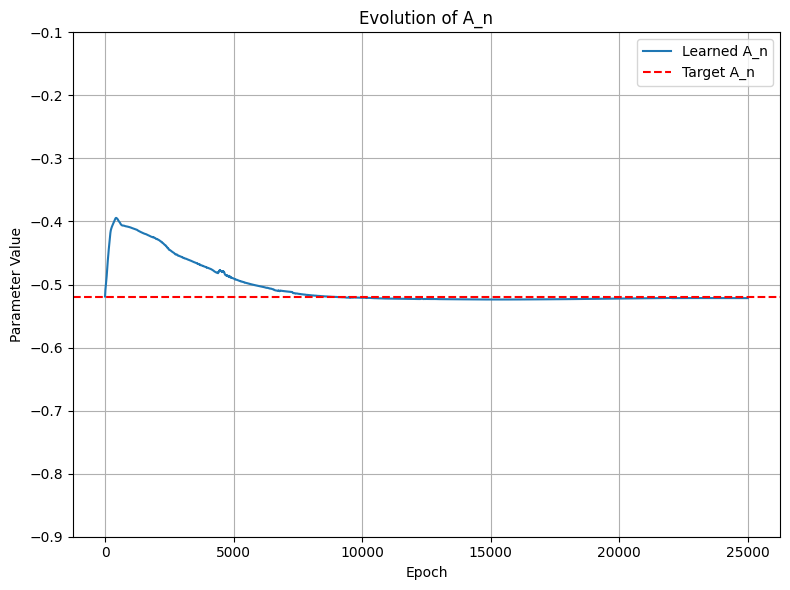

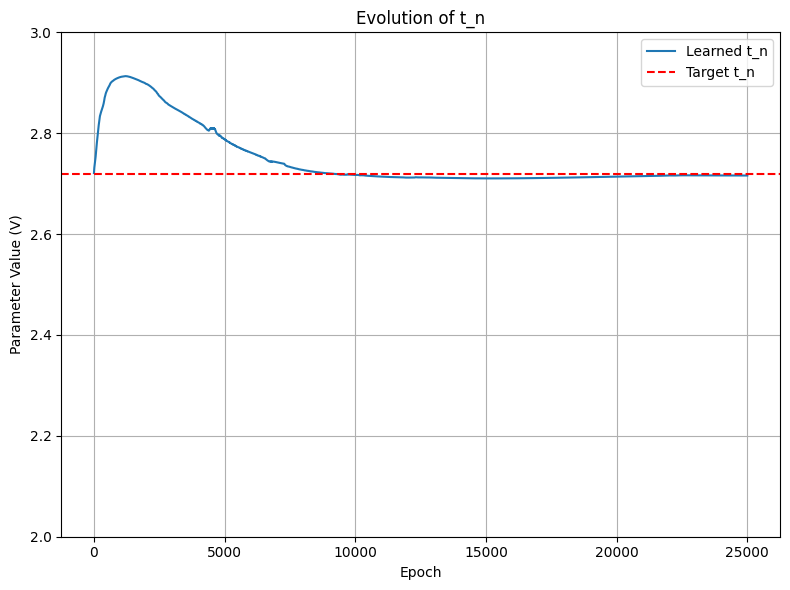

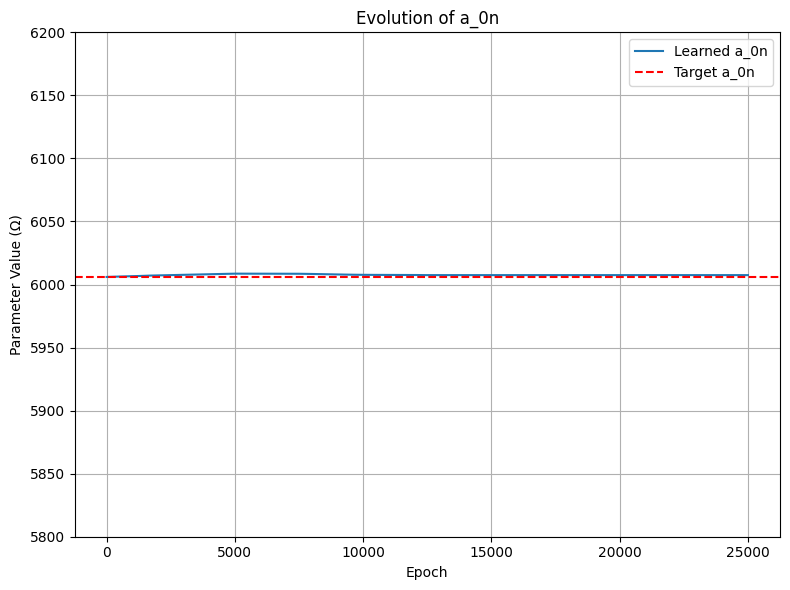

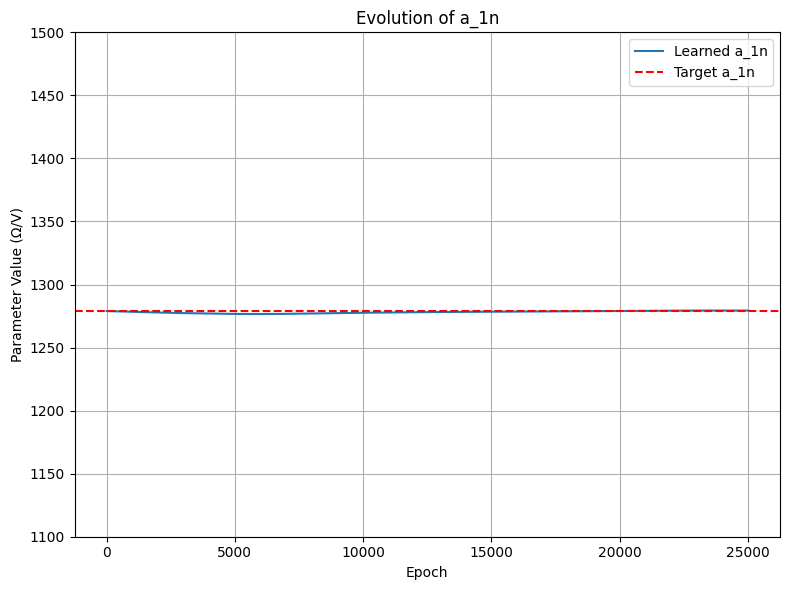

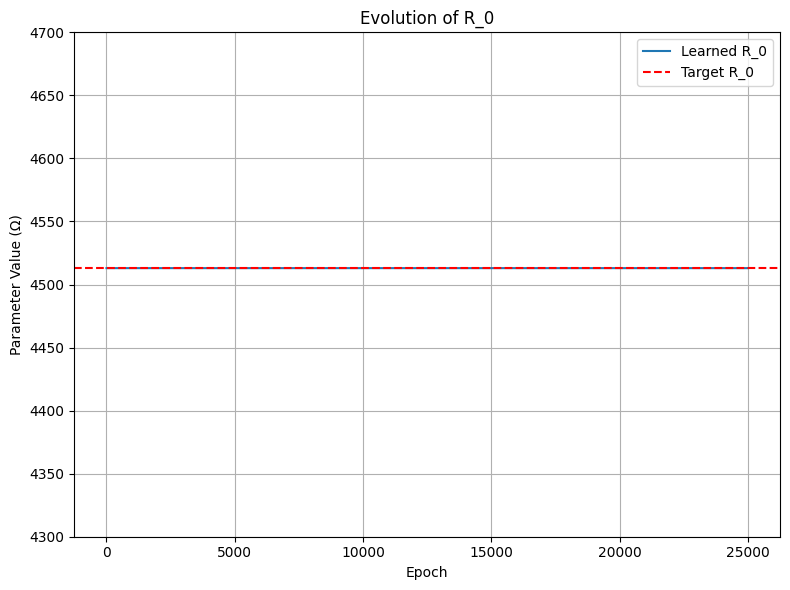

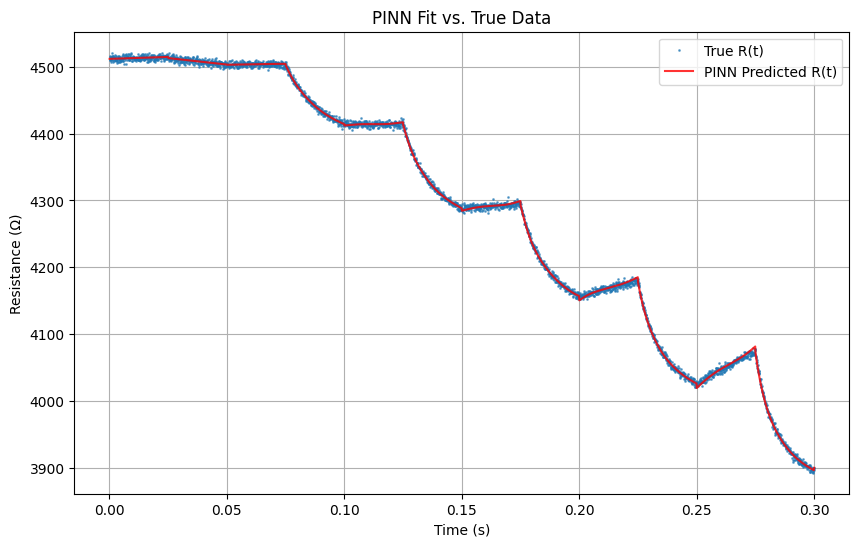

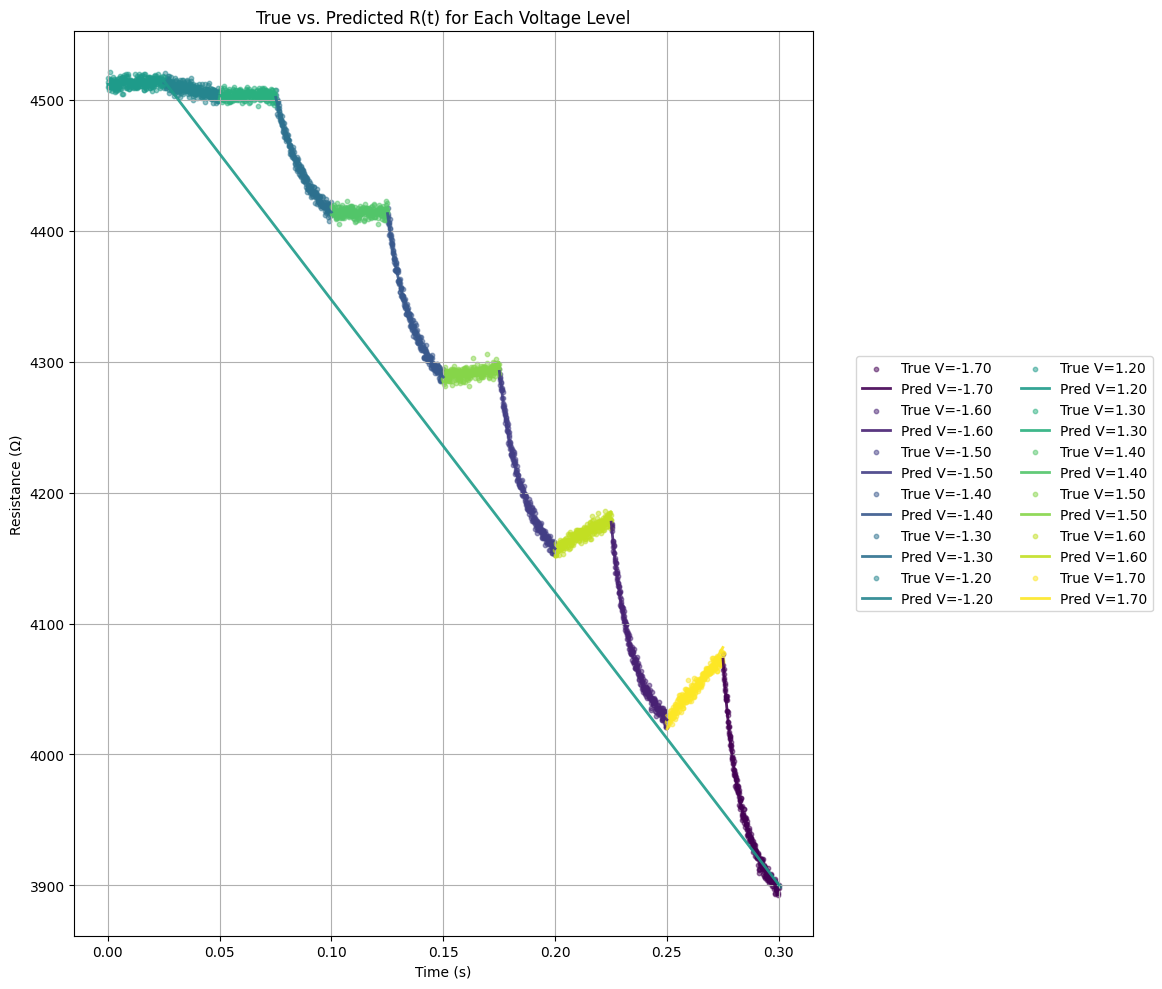

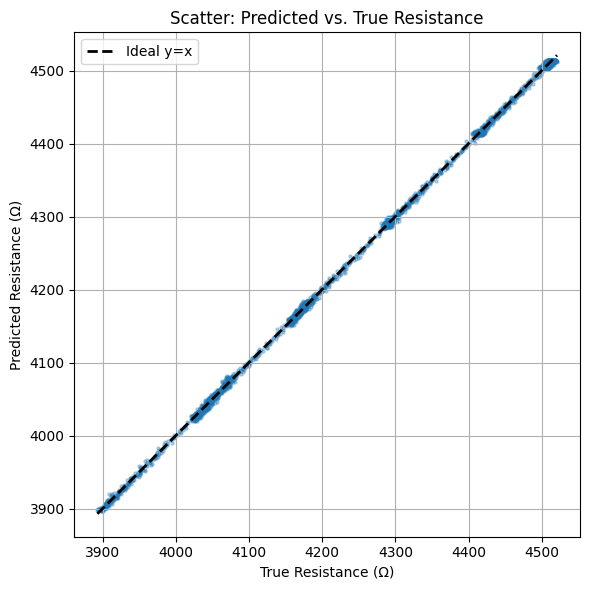

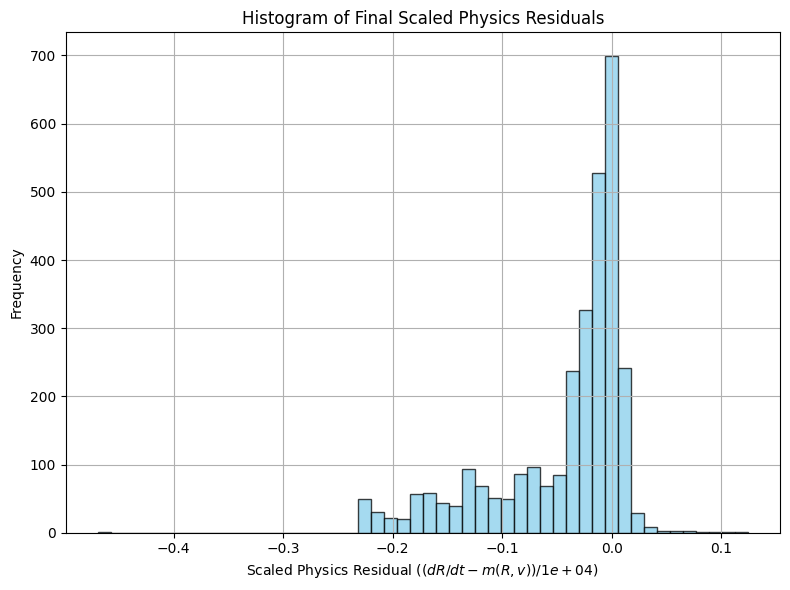

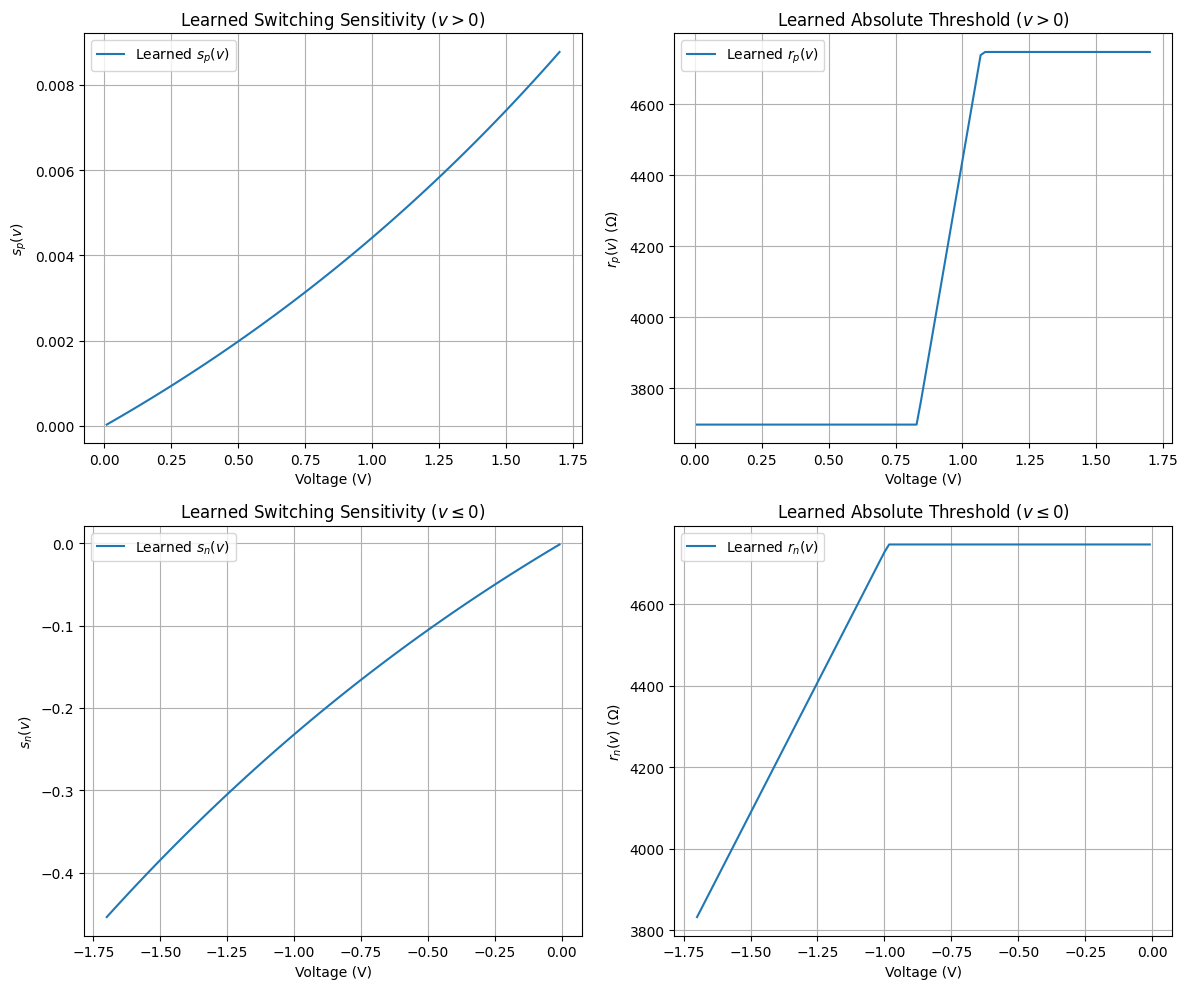

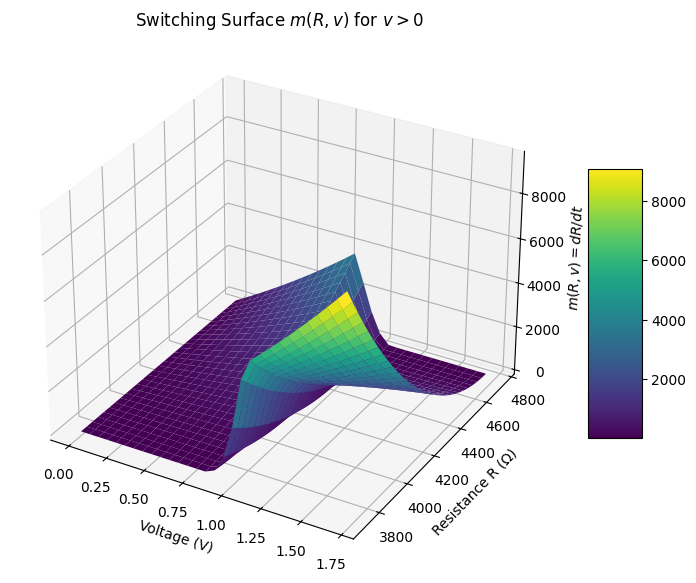

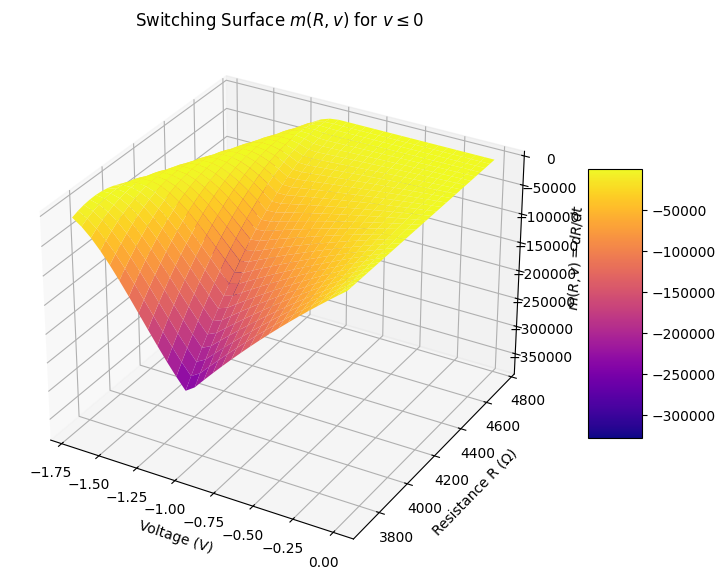

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting
import collections

# --- Model Definition ---
class PINN(nn.Module):
    def __init__(self, R_min=1000.0, R_max=7000.0, dRdt_scale=1.0e4,
                 t_min_norm=0.0, t_range_norm=1.0, v_min_norm=0.0, v_range_norm=1.0):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

        self.A_p = nn.Parameter(torch.tensor(0.011))
        self.t_p = nn.Parameter(torch.tensor(2.00))
        self.a_1p = nn.Parameter(torch.tensor(4300.0))
        self.a_0p = nn.Parameter(torch.tensor(65.61))
        self.A_n = nn.Parameter(torch.tensor(-0.58))
        self.t_n = nn.Parameter(torch.tensor(2.00))
        self.a_0n = nn.Parameter(torch.tensor(6000.0))
        self.a_1n = nn.Parameter(torch.tensor(1200.0))
        self.R_0 = nn.Parameter(torch.tensor(4513.0))

        self.R_min = R_min
        self.R_max = R_max
        self.dRdt_scale = dRdt_scale

        self.t_min_norm = t_min_norm
        self.t_range_norm = t_range_norm
        self.v_min_norm = v_min_norm
        self.v_range_norm = v_range_norm

    def forward(self, inputs_normalized):
        R_normalized = self.net(inputs_normalized)
        return self.R_min + R_normalized * (self.R_max - self.R_min)

    def s_p(self, v):
        v_tensor = torch.as_tensor(v, dtype=torch.float32, device=self.A_p.device)
        t_p_safe = torch.where(torch.abs(self.t_p) > 1e-9, self.t_p, torch.sign(self.t_p) * 1e-9 if torch.abs(self.t_p) > 0 else 1e-9)
        return self.A_p * (-1 + torch.exp(torch.abs(v_tensor) / t_p_safe))

    def r_p(self, v):
        v_tensor = torch.as_tensor(v, dtype=torch.float32, device=self.a_0p.device)
        r = self.a_0p + self.a_1p * v_tensor
        return torch.clamp(r, self.R_min, self.R_max)

    def f_p(self, R, v):
        R_tensor = torch.as_tensor(R, dtype=torch.float32, device=self.a_0p.device)
        r_v = self.r_p(v)
        return (r_v - R_tensor) ** 2

    def m_p_calc(self, R, v):
        return self.s_p(v) * self.f_p(R, v)

    def s_n(self, v):
        v_tensor = torch.as_tensor(v, dtype=torch.float32, device=self.A_n.device)
        t_n_safe = torch.where(torch.abs(self.t_n) > 1e-9, self.t_n, torch.sign(self.t_n) * 1e-9 if torch.abs(self.t_n) > 0 else 1e-9)
        return self.A_n * (-1 + torch.exp(torch.abs(v_tensor) / t_n_safe))

    def r_n(self, v):
        v_tensor = torch.as_tensor(v, dtype=torch.float32, device=self.a_0n.device)
        r = self.a_0n + self.a_1n * v_tensor
        return torch.clamp(r, self.R_min, self.R_max)

    def f_n(self, R, v):
        R_tensor = torch.as_tensor(R, dtype=torch.float32, device=self.a_0n.device)
        r_v = self.r_n(v)
        return (R_tensor - r_v) ** 2

    def m_n_calc(self, R, v):
        return self.s_n(v) * self.f_n(R, v)

    def physics_loss(self, inputs_normalized):
        if not inputs_normalized.requires_grad:
             inputs_normalized.requires_grad_(True)

        v_normalized = inputs_normalized[:, 1:2]
        v_original = v_normalized * self.v_range_norm + self.v_min_norm
        R = self.forward(inputs_normalized)

        if self.t_range_norm < 1e-9:
            dR_dt_original = torch.zeros_like(R, device=R.device)
        else:
            grad_R_wrt_normalized_inputs = torch.autograd.grad(
                outputs=R,
                inputs=inputs_normalized,
                grad_outputs=torch.ones_like(R),
                create_graph=self.training,
                retain_graph=self.training,
                allow_unused=False
            )[0]
            dR_dt_normalized = grad_R_wrt_normalized_inputs[:, 0:1]
            dR_dt_original = dR_dt_normalized / self.t_range_norm

        R = R.to(v_original.device)
        positive_mask = v_original > 0
        s_v = torch.where(positive_mask, self.s_p(v_original), self.s_n(v_original))
        f_R_v = torch.where(positive_mask, self.f_p(R, v_original), self.f_n(R, v_original))
        m_R_v_original = s_v * f_R_v
        residual = dR_dt_original - m_R_v_original
        current_dRdt_scale = self.dRdt_scale if self.dRdt_scale > 1e-9 else 1.0
        scaled_residual = residual / current_dRdt_scale
        physics_loss_term = torch.mean(scaled_residual ** 2)
        mean_abs_residual = torch.mean(torch.abs(residual))
        return physics_loss_term, dR_dt_original, m_R_v_original, mean_abs_residual, residual

# Target parameters for DUT1 
target_params_global = {
    'A_p': 0.01, 't_p': 2.45, 'a_1p': 4370.0, 'a_0p': 71.61,
    'A_n': -0.52, 't_n': 2.72, 'a_0n': 6006.0, 'a_1n': 1279.0,
    'R_0': 4513.0
}

# --- Loss Computation ---
def compute_loss(model, inputs_tensor, R_tensor, inputs_physics_tensor, batch_size=1000):
    # Using global target_params_global
    data_loss = torch.tensor(0.0, device=model.R_0.device)
    num_data_points = inputs_tensor.shape[0]
    if num_data_points > 0:
        current_data_loss = 0.0
        for i in range(0, num_data_points, batch_size):
            batch_inputs = inputs_tensor[i:i+batch_size]; batch_R = R_tensor[i:i+batch_size]
            R_pred = model(batch_inputs)
            batch_data_loss_term = torch.mean(((R_pred - batch_R) / (model.R_max - model.R_min)) ** 2)
            current_data_loss += batch_data_loss_term * (batch_inputs.shape[0] / float(num_data_points))
        data_loss = current_data_loss

    physics_loss_val = torch.tensor(0.0, device=model.R_0.device)
    mean_residual_val = torch.tensor(0.0, device=model.R_0.device)
    num_physics_points = inputs_physics_tensor.shape[0]
    if num_physics_points > 0:
        current_physics_loss = 0.0; current_mean_residual = 0.0
        for i in range(0, num_physics_points, batch_size):
            batch_inputs_physics = inputs_physics_tensor[i:i+batch_size]
            if not batch_inputs_physics.requires_grad: batch_inputs_physics.requires_grad_(True)
            batch_physics_loss_term, _, _, batch_mean_abs_residual, _ = model.physics_loss(batch_inputs_physics)
            current_physics_loss += batch_physics_loss_term * (batch_inputs_physics.shape[0] / float(num_physics_points))
            current_mean_residual += batch_mean_abs_residual * (batch_inputs_physics.shape[0] / float(num_physics_points))
        physics_loss_val = current_physics_loss
        mean_residual_val = current_mean_residual
    

    data_loss_weight = 1000.0; physics_loss_weight = 1.0
    total_loss = data_loss_weight * data_loss + physics_loss_weight * physics_loss_val 
    return total_loss, data_loss, physics_loss_val, mean_residual_val

# --- Data Generation (DUT1 Aligned) ---
def generate_pulse_train_data(t_max_duration, v_values_seq, R_0_start,
                              A_p_true, t_p_true, a_0p_true, a_1p_true,
                              A_n_true, t_n_true, a_0n_true, a_1n_true,
                              pulses_per_v_setting=10, time_step_per_pulse=0.0001,
                              noise_level=0.005, R_min_clip=1000.0, R_max_clip=7000.0,
                              plot_generated_data=True):
    T_list, V_list, R_list = [], [], []; current_R = R_0_start; actual_time = 0.0; v_idx = 0
    while actual_time < t_max_duration:
        if not v_values_seq: break
        v_i = v_values_seq[v_idx % len(v_values_seq)]
        for _ in range(pulses_per_v_setting):
            if actual_time >= t_max_duration: break
            t_p_true_safe = t_p_true if abs(t_p_true) > 1e-9 else (np.sign(t_p_true) * 1e-9 if t_p_true != 0 else 1e-9)
            t_n_true_safe = t_n_true if abs(t_n_true) > 1e-9 else (np.sign(t_n_true) * 1e-9 if t_n_true != 0 else 1e-9)
            if v_i > 0:
                s_v = A_p_true * (-1 + np.exp(np.abs(v_i) / t_p_true_safe))
                r_v = np.clip(a_0p_true + a_1p_true * v_i, R_min_clip, R_max_clip)
            else: # v_i <= 0
                s_v = A_n_true * (-1 + np.exp(np.abs(v_i) / t_n_true_safe))
                r_v = np.clip(a_0n_true + a_1n_true * v_i, R_min_clip, R_max_clip)
            term = s_v * (r_v - current_R) * time_step_per_pulse
            denominator = 1.0 + term
            denominator = np.clip(denominator, 1e-9, np.inf)
            current_R = (current_R + s_v * r_v * (r_v - current_R) * time_step_per_pulse) / denominator
            current_R = np.clip(current_R, R_min_clip, R_max_clip)
            if np.isnan(current_R) or np.isinf(current_R):
                error_context = (f"s_v={s_v:.4e}, r_v={r_v:.4e}, current_R_before_update={R_list[-1] if R_list else R_0_start:.4e}, "
                                 f"time_step={time_step_per_pulse:.1e}, v_i={v_i:.2f}, actual_time={actual_time:.4f}")
                raise ValueError(f"NaN/Inf in R calculation. Context: {error_context}")
            actual_time += time_step_per_pulse
            T_list.append(actual_time); V_list.append(v_i); R_list.append(current_R)
        v_idx += 1
        if not T_list and actual_time >= t_max_duration : break
    if not R_list: return np.array([]), np.array([]), np.array([])
    R_array, T_array, V_array = np.array(R_list), np.array(T_list), np.array(V_list)
    if noise_level > 0 and len(R_array) > 0:
        R_range_for_noise = R_array.max() - R_array.min()
        if R_range_for_noise < 1e-6: R_range_for_noise = R_max_clip - R_min_clip
        if R_range_for_noise < 1e-6: R_range_for_noise = 1.0
        R_noise = np.random.normal(0, noise_level * R_range_for_noise, R_array.shape)
        R_array += R_noise; R_array = np.clip(R_array, R_min_clip, R_max_clip)
    if plot_generated_data:
        plt.figure(figsize=(10, 6))
        unique_v_plot = np.unique(V_array)
        for v_val_plot in unique_v_plot:
            mask = np.abs(V_array - v_val_plot) < 1e-3
            if np.any(mask):
                sort_indices = np.argsort(T_array[mask])
                plt.plot(T_array[mask][sort_indices], R_array[mask][sort_indices], 'o-', markersize=3, label=f'V={v_val_plot:.2f}')
        plt.xlabel('Time (s)'); plt.ylabel('Resistance (Ω)'); plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title('Generated Synthetic R(t) Data (DUT1-like)'); plt.grid(True); plt.tight_layout(); plt.show()
    return T_array, V_array, R_array

# --- Data Preparation ---
def normalize_data(T, V):
    t_min, t_max = np.min(T), np.max(T); v_min, v_max = np.min(V), np.max(V)
    t_range = t_max - t_min; v_range = v_max - v_min
    if t_range < 1e-9: t_range = 1.0
    if v_range < 1e-9: v_range = 1.0
    T_norm = (T - t_min) / t_range if t_range > 1e-9 else np.zeros_like(T)
    V_norm = (V - v_min) / v_range if v_range > 1e-9 else np.zeros_like(V)
    return T_norm, V_norm, t_min, t_range, v_min, v_range

# --- Training Setup ---

R0_DUT1_for_data_gen = target_params_global['R_0']
time_step_data_gen = 0.0001; pulses_per_v_setting_data_gen = 250
v_levels_DUT1_data_gen = np.arange(1.2, 1.71, 0.1); v_pulse_sequence_data_gen = []
for v_level in v_levels_DUT1_data_gen:
    v_pulse_sequence_data_gen.append(v_level); v_pulse_sequence_data_gen.append(-v_level)
t_simulation_duration_data_gen = len(v_pulse_sequence_data_gen) * pulses_per_v_setting_data_gen * time_step_data_gen

T_data, V_data, R_data = generate_pulse_train_data(
    t_simulation_duration_data_gen, v_pulse_sequence_data_gen, R0_DUT1_for_data_gen,
    target_params_global['A_p'], target_params_global['t_p'], target_params_global['a_1p'], target_params_global['a_0p'], 
    target_params_global['A_n'], target_params_global['t_n'], target_params_global['a_0n'], target_params_global['a_1n'],
    pulses_per_v_setting=pulses_per_v_setting_data_gen, time_step_per_pulse=time_step_data_gen,
    noise_level=0.005, 
    R_min_clip= 1000.0, 
    R_max_clip= 7000.0,
    plot_generated_data=True)

if len(T_data) == 0: raise ValueError("Data generation resulted in no data points.")

T_norm, V_norm, t_min, t_range, v_min, v_range = normalize_data(T_data, V_data)
inputs = np.stack([T_norm, V_norm], axis=1)
inputs_tensor = torch.tensor(inputs, dtype=torch.float32)
R_tensor = torch.tensor(R_data, dtype=torch.float32).unsqueeze(1)
inputs_physics_tensor = inputs_tensor.clone().detach().requires_grad_(True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print(f"Using device: {device}")

model_R_min = R_data.min() * 0.95 if len(R_data) > 0 else 1000.0
model_R_max = R_data.max() * 1.05 if len(R_data) > 0 else 7000.0

model = PINN(R_min=model_R_min, R_max=model_R_max, dRdt_scale=1.0e4,
             t_min_norm=t_min, t_range_norm=t_range, v_min_norm=v_min, v_range_norm=v_range).to(device)

inputs_tensor = inputs_tensor.to(device); R_tensor = R_tensor.to(device)
inputs_physics_tensor = inputs_physics_tensor.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=500, verbose=True, min_lr=1e-6)
n_epochs = 25000
total_loss_list, data_loss_list, physics_loss_list, lr_list = [], [], [], []

# For storing parameter history
param_names = ['A_p', 't_p', 'a_1p', 'a_0p', 'A_n', 't_n', 'a_0n', 'a_1n', 'R_0']
param_history = collections.defaultdict(list)


print("Starting training...")
for epoch in range(n_epochs):
    model.train(); optimizer.zero_grad()
    total_loss, data_loss, physics_loss_val, mean_residual_val = compute_loss(
        model, inputs_tensor, R_tensor, inputs_physics_tensor, batch_size=1024)
    if torch.isnan(total_loss): print(f"Epoch {epoch}: NaN loss detected. Stopping."); break
    total_loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0); optimizer.step()
    total_loss_list.append(total_loss.item()); data_loss_list.append(data_loss.item())
    physics_loss_list.append(physics_loss_val.item()); lr_list.append(optimizer.param_groups[0]['lr'])
    
    # Store current parameter values
    for name in param_names:
        param_history[name].append(getattr(model, name).item())
        
    scheduler.step(total_loss)
    if epoch % 100 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch}/{n_epochs-1}: Total Loss={total_loss.item():.4e}, Data Loss={data_loss.item():.4e}, "
              f"Physics Loss={physics_loss_val.item():.4e}, Mean Residual={mean_residual_val.item():.4e}, LR={optimizer.param_groups[0]['lr']:.1e}")
print("Training finished.")

model.eval()
with torch.no_grad():
    inputs_for_eval = inputs_tensor.to(device)
    R_pred_normalized_eval = model.net(inputs_for_eval)
    R_pred_eval = model.R_min + R_pred_normalized_eval * (model.R_max - model.R_min)
    R_pred_eval_cpu = R_pred_eval.cpu().numpy()

if not inputs_physics_tensor.requires_grad:
    inputs_physics_tensor.requires_grad_(True)
    
_, _, _, _, final_residuals_tensor = model.physics_loss(inputs_physics_tensor)
final_residuals_cpu = final_residuals_tensor.cpu().detach().numpy() / model.dRdt_scale

print("\n--- Trained Model Parameters ---")
for name, param_val in model.named_parameters(): 
    if param_val.requires_grad and param_val.numel() == 1: print(f"{name}: {param_val.data.cpu().item():.5f}")


# --- Plot Loss Curves ---
plt.figure(figsize=(12, 6)); plt.subplot(1, 2, 1)
plt.plot(total_loss_list, label='Total Loss'); plt.plot(data_loss_list, label='Data Loss (Weighted)')
plt.plot(physics_loss_list, label='Physics Loss (Weighted)'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Loss Curves'); plt.legend(); plt.grid(True); plt.yscale('log')
plt.subplot(1, 2, 2); plt.plot(lr_list, label='Learning Rate'); plt.xlabel('Epoch'); plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule'); plt.legend(); plt.grid(True); plt.yscale('log')
plt.tight_layout(); plt.show()



epochs_array = np.arange(len(total_loss_list))

# Default figure size 
figure_width = 8  # inches
figure_height = 6 # inches

# --- Plot for A_p ---
plt.figure(figsize=(figure_width, figure_height))
parameter_name = 'A_p'
if parameter_name in param_history and parameter_name in target_params_global:
    plt.plot(epochs_array, param_history[parameter_name], label=f'Learned {parameter_name}')
    plt.axhline(y=target_params_global[parameter_name], color='r', linestyle='--', label=f'Target {parameter_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Parameter Value')
    plt.title(f'Evolution of {parameter_name}')

    # --- EDIT Y-AXIS RANGE FOR A_p HERE ---
    Ap_min_y_value = 0.001  
    Ap_max_y_value = 0.030  
    plt.ylim(Ap_min_y_value, Ap_max_y_value)
    # --- END OF Y-AXIS EDIT ---

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Data for parameter {parameter_name} not available for plotting or target not defined.")

# --- Plot for t_p ---
plt.figure(figsize=(figure_width, figure_height))
parameter_name = 't_p'
if parameter_name in param_history and parameter_name in target_params_global:
    plt.plot(epochs_array, param_history[parameter_name], label=f'Learned {parameter_name}')
    plt.axhline(y=target_params_global[parameter_name], color='r', linestyle='--', label=f'Target {parameter_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Parameter Value (V)')
    plt.title(f'Evolution of {parameter_name}')

    # --- EDIT Y-AXIS RANGE FOR t_p HERE ---
    tp_min_y_value = 2.0
    tp_max_y_value = 3.0
    plt.ylim(tp_min_y_value, tp_max_y_value)
    # --- END OF Y-AXIS EDIT ---

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Data for parameter {parameter_name} not available for plotting or target not defined.")

# --- Plot for a_0p ---

plt.figure(figsize=(figure_width, figure_height))
parameter_name = 'a_0p'
if parameter_name in param_history and parameter_name in target_params_global:
    plt.plot(epochs_array, param_history[parameter_name], label=f'Learned {parameter_name}')
    plt.axhline(y=target_params_global[parameter_name], color='r', linestyle='--', label=f'Target {parameter_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Parameter Value (Ω)')
    plt.title(f'Evolution of {parameter_name}')

    # --- EDIT Y-AXIS RANGE FOR a_0p HERE ---
    a0p_min_y_value = 60
    a0p_max_y_value = 85
    plt.ylim(a0p_min_y_value, a0p_max_y_value)
    # --- END OF Y-AXIS EDIT ---

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Data for parameter {parameter_name} not available for plotting or target not defined.")

# --- Plot for a_1p ---

plt.figure(figsize=(figure_width, figure_height))
parameter_name = 'a_1p'
if parameter_name in param_history and parameter_name in target_params_global:
    plt.plot(epochs_array, param_history[parameter_name], label=f'Learned {parameter_name}')
    plt.axhline(y=target_params_global[parameter_name], color='r', linestyle='--', label=f'Target {parameter_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Parameter Value (Ω/V)')
    plt.title(f'Evolution of {parameter_name}')

    # --- EDIT Y-AXIS RANGE FOR a_1p HERE ---
    a1p_min_y_value = 4000
    a1p_max_y_value = 4700
    plt.ylim(a1p_min_y_value, a1p_max_y_value)
    # --- END OF Y-AXIS EDIT ---

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Data for parameter {parameter_name} not available for plotting or target not defined.")

# --- Plot for A_n ---
plt.figure(figsize=(figure_width, figure_height))
parameter_name = 'A_n'
if parameter_name in param_history and parameter_name in target_params_global:
    plt.plot(epochs_array, param_history[parameter_name], label=f'Learned {parameter_name}')
    plt.axhline(y=target_params_global[parameter_name], color='r', linestyle='--', label=f'Target {parameter_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Parameter Value')
    plt.title(f'Evolution of {parameter_name}')

    # --- EDIT Y-AXIS RANGE FOR A_n HERE ---
    An_min_y_value = -0.9
    An_max_y_value = -0.1
    plt.ylim(An_min_y_value, An_max_y_value)
    # --- END OF Y-AXIS EDIT ---

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Data for parameter {parameter_name} not available for plotting or target not defined.")

# --- Plot for t_n ---
plt.figure(figsize=(figure_width, figure_height))
parameter_name = 't_n'
if parameter_name in param_history and parameter_name in target_params_global:
    plt.plot(epochs_array, param_history[parameter_name], label=f'Learned {parameter_name}')
    plt.axhline(y=target_params_global[parameter_name], color='r', linestyle='--', label=f'Target {parameter_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Parameter Value (V)')
    plt.title(f'Evolution of {parameter_name}')

    # --- EDIT Y-AXIS RANGE FOR t_n HERE ---
    tn_min_y_value = 2.0
    tn_max_y_value = 3.0
    plt.ylim(tn_min_y_value, tn_max_y_value)
    # --- END OF Y-AXIS EDIT ---

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Data for parameter {parameter_name} not available for plotting or target not defined.")

# --- Plot for a_0n ---
plt.figure(figsize=(figure_width, figure_height))
parameter_name = 'a_0n'
if parameter_name in param_history and parameter_name in target_params_global:
    plt.plot(epochs_array, param_history[parameter_name], label=f'Learned {parameter_name}')
    plt.axhline(y=target_params_global[parameter_name], color='r', linestyle='--', label=f'Target {parameter_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Parameter Value (Ω)')
    plt.title(f'Evolution of {parameter_name}')

    # --- EDIT Y-AXIS RANGE FOR a_0n HERE ---
    a0n_min_y_value = 5800
    a0n_max_y_value = 6200
    plt.ylim(a0n_min_y_value, a0n_max_y_value)
    # --- END OF Y-AXIS EDIT ---

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Data for parameter {parameter_name} not available for plotting or target not defined.")

# --- Plot for a_1n ---
plt.figure(figsize=(figure_width, figure_height))
parameter_name = 'a_1n'
if parameter_name in param_history and parameter_name in target_params_global:
    plt.plot(epochs_array, param_history[parameter_name], label=f'Learned {parameter_name}')
    plt.axhline(y=target_params_global[parameter_name], color='r', linestyle='--', label=f'Target {parameter_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Parameter Value (Ω/V)')
    plt.title(f'Evolution of {parameter_name}')

    # --- EDIT Y-AXIS RANGE FOR a_1n HERE ---
    a1n_min_y_value = 1100
    a1n_max_y_value = 1500
    plt.ylim(a1n_min_y_value, a1n_max_y_value)
    # --- END OF Y-AXIS EDIT ---

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Data for parameter {parameter_name} not available for plotting or target not defined.")

# --- Plot for R_0 ---
plt.figure(figsize=(figure_width, figure_height))
parameter_name = 'R_0'
if parameter_name in param_history and parameter_name in target_params_global:
    plt.plot(epochs_array, param_history[parameter_name], label=f'Learned {parameter_name}')
    plt.axhline(y=target_params_global[parameter_name], color='r', linestyle='--', label=f'Target {parameter_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Parameter Value (Ω)')
    plt.title(f'Evolution of {parameter_name}')

    # --- EDIT Y-AXIS RANGE FOR R_0 HERE ---
    R0_min_y_value = 4300
    R0_max_y_value = 4700
    plt.ylim(R0_min_y_value, R0_max_y_value)
    # --- END OF Y-AXIS EDIT ---

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Data for parameter {parameter_name} not available for plotting or target not defined.")


# --- Plot True vs Predicted R(t) (All Data) ---
plt.figure(figsize=(10,6))
plt.plot(T_data, R_data, label="True R(t)", alpha=0.6, marker='.', linestyle='None', markersize=2)
plt.plot(T_data, R_pred_eval_cpu, label="PINN Predicted R(t)", alpha=0.8, color='red', linestyle='-')
plt.xlabel("Time (s)"); plt.ylabel("Resistance (Ω)"); plt.legend(); plt.title("PINN Fit vs. True Data"); plt.grid(True); plt.show()

# --- Plot R(t) for Each Voltage Level ---
unique_v = np.unique(V_data); plt.figure(figsize=(14, 10)); num_unique_v = len(unique_v)
colors = plt.cm.viridis(np.linspace(0, 1, num_unique_v))
for idx, v_val in enumerate(unique_v):
    mask = np.abs(V_data - v_val) < 1e-3
    if np.any(mask):
        sort_idx = np.argsort(T_data[mask])
        plt.scatter(T_data[mask][sort_idx], R_data[mask][sort_idx], s=10, alpha=0.5, label=f'True V={v_val:.2f}', color=colors[idx])
        plt.plot(T_data[mask][sort_idx], R_pred_eval_cpu[mask][sort_idx], '-', alpha=0.9, label=f'Pred V={v_val:.2f}', color=colors[idx], linewidth=2)
plt.xlabel('Time (s)'); plt.ylabel('Resistance (Ω)'); plt.title('True vs. Predicted R(t) for Each Voltage Level')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=(1 if num_unique_v < 10 else 2))
plt.grid(True); plt.tight_layout(rect=[0, 0, 0.85, 1]); plt.show()

# --- Scatter Plot: Predicted vs True Resistance ---
plt.figure(figsize=(6,6)); plt.scatter(R_data, R_pred_eval_cpu, s=5, alpha=0.3)
plt.plot([R_data.min(), R_data.max()], [R_data.min(), R_data.max()], 'k--', lw=2, label='Ideal y=x')
plt.xlabel('True Resistance (Ω)'); plt.ylabel('Predicted Resistance (Ω)'); plt.title('Scatter: Predicted vs. True Resistance')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# --- Plot Histogram of Final Physics Residuals ---
plt.figure(figsize=(8, 6))
plt.hist(final_residuals_cpu.flatten(), bins=50, alpha=0.75, color='skyblue', edgecolor='black')
plt.xlabel(f"Scaled Physics Residual ($(dR/dt - m(R,v)) / {model.dRdt_scale:.0e}$)")
plt.ylabel("Frequency")
plt.title("Histogram of Final Scaled Physics Residuals")
plt.grid(True); plt.tight_layout(); plt.show()

# --- Plot Learned Physical Functions s(v) and r(v) ---
model.eval()
v_plot_range_min = V_data.min() if len(V_data)>0 else -2.0
v_plot_range_max = V_data.max() if len(V_data)>0 else 2.0
v_plot_fine = torch.linspace(v_plot_range_min, v_plot_range_max, 200).unsqueeze(1).to(device)

with torch.no_grad():
    s_p_learned = model.s_p(v_plot_fine[v_plot_fine > 0]).cpu().numpy() if torch.any(v_plot_fine > 0) else np.array([])
    r_p_learned = model.r_p(v_plot_fine[v_plot_fine > 0]).cpu().numpy() if torch.any(v_plot_fine > 0) else np.array([])
    s_n_learned = model.s_n(v_plot_fine[v_plot_fine <= 0]).cpu().numpy() if torch.any(v_plot_fine <= 0) else np.array([])
    r_n_learned = model.r_n(v_plot_fine[v_plot_fine <= 0]).cpu().numpy() if torch.any(v_plot_fine <= 0) else np.array([])

v_plot_fine_p = v_plot_fine[v_plot_fine > 0].cpu().numpy()
v_plot_fine_n = v_plot_fine[v_plot_fine <= 0].cpu().numpy()

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
if len(v_plot_fine_p) > 0 and len(s_p_learned)>0 : axs[0, 0].plot(v_plot_fine_p, s_p_learned, label='Learned $s_p(v)$')
axs[0, 0].set_xlabel('Voltage (V)'); axs[0, 0].set_ylabel('$s_p(v)$'); axs[0, 0].set_title('Learned Switching Sensitivity ($v>0$)')
axs[0, 0].grid(True); axs[0, 0].legend()
if len(v_plot_fine_p) > 0 and len(r_p_learned)>0: axs[0, 1].plot(v_plot_fine_p, r_p_learned, label='Learned $r_p(v)$')
axs[0, 1].set_xlabel('Voltage (V)'); axs[0, 1].set_ylabel('$r_p(v)$ (Ω)'); axs[0, 1].set_title('Learned Absolute Threshold ($v>0$)')
axs[0, 1].grid(True); axs[0, 1].legend()
if len(v_plot_fine_n) > 0 and len(s_n_learned)>0: axs[1, 0].plot(v_plot_fine_n, s_n_learned, label='Learned $s_n(v)$')
axs[1, 0].set_xlabel('Voltage (V)'); axs[1, 0].set_ylabel('$s_n(v)$'); axs[1, 0].set_title('Learned Switching Sensitivity ($v \\leq 0$)')
axs[1, 0].grid(True); axs[1, 0].legend()
if len(v_plot_fine_n) > 0 and len(r_n_learned)>0: axs[1, 1].plot(v_plot_fine_n, r_n_learned, label='Learned $r_n(v)$')
axs[1, 1].set_xlabel('Voltage (V)'); axs[1, 1].set_ylabel('$r_n(v)$ (Ω)'); axs[1, 1].set_title('Learned Absolute Threshold ($v \\leq 0$)')
axs[1, 1].grid(True); axs[1, 1].legend()
plt.tight_layout(); plt.show()

# --- NEW: Plot Switching Surface m(R,v) ---
model.eval()
R_plot_min = model.R_min
R_plot_max = model.R_max
R_grid_points = 30
V_grid_points = 30

# For v > 0
v_positive_surface_vals = np.linspace(1e-3, v_plot_range_max if v_plot_range_max > 0 else 2.0, V_grid_points)
R_surface_vals = np.linspace(R_plot_min, R_plot_max, R_grid_points)
V_p_mesh_np, R_p_mesh_np = np.meshgrid(v_positive_surface_vals, R_surface_vals, indexing='xy')
m_R_v_positive_np = np.zeros_like(V_p_mesh_np)

if len(v_positive_surface_vals) > 0 and v_positive_surface_vals.max() > 0:
    with torch.no_grad():
        for i in range(V_p_mesh_np.shape[0]):
            for j in range(V_p_mesh_np.shape[1]):
                R_val = torch.tensor([[R_p_mesh_np[i,j]]], dtype=torch.float32).to(device)
                v_val = torch.tensor([[V_p_mesh_np[i,j]]], dtype=torch.float32).to(device)
                m_R_v_positive_np[i,j] = model.m_p_calc(R_val, v_val).squeeze().cpu().numpy()

    fig_p = plt.figure(figsize=(10, 7))
    ax_p = fig_p.add_subplot(111, projection='3d')
    if V_p_mesh_np.size > 0 :
        surf_p = ax_p.plot_surface(V_p_mesh_np, R_p_mesh_np, m_R_v_positive_np, cmap='viridis', edgecolor='none', rstride=1, cstride=1)
        ax_p.set_xlabel('Voltage (V)'); ax_p.set_ylabel('Resistance R (Ω)'); ax_p.set_zlabel('$m(R,v) = dR/dt$')
        ax_p.set_title('Switching Surface $m(R,v)$ for $v > 0$'); fig_p.colorbar(surf_p, shrink=0.5, aspect=5)
    else:
        ax_p.text(0.5, 0.5, 0.5, "No valid positive voltage data for surface plot", transform=ax_p.transAxes, ha='center', va='center')
    plt.show()

# For v <= 0
v_negative_surface_vals = np.linspace(v_plot_range_min if v_plot_range_min < 0 else -2.0, 0, V_grid_points)
V_n_mesh_np, R_n_mesh_np = np.meshgrid(v_negative_surface_vals, R_surface_vals, indexing='xy')
m_R_v_negative_np = np.zeros_like(V_n_mesh_np)

if len(v_negative_surface_vals) > 0 and v_negative_surface_vals.min() <= 0:
    with torch.no_grad():
        for i in range(V_n_mesh_np.shape[0]):
            for j in range(V_n_mesh_np.shape[1]):
                R_val = torch.tensor([[R_n_mesh_np[i,j]]], dtype=torch.float32).to(device)
                v_val = torch.tensor([[V_n_mesh_np[i,j]]], dtype=torch.float32).to(device)
                m_R_v_negative_np[i,j] = model.m_n_calc(R_val, v_val).squeeze().cpu().numpy()

    fig_n = plt.figure(figsize=(10, 7))
    ax_n = fig_n.add_subplot(111, projection='3d')
    if V_n_mesh_np.size > 0:
        surf_n = ax_n.plot_surface(V_n_mesh_np, R_n_mesh_np, m_R_v_negative_np, cmap='plasma', edgecolor='none', rstride=1, cstride=1)
        ax_n.set_xlabel('Voltage (V)'); ax_n.set_ylabel('Resistance R (Ω)'); ax_n.set_zlabel('$m(R,v) = dR/dt$')
        ax_n.set_title('Switching Surface $m(R,v)$ for $v \\leq 0$'); fig_n.colorbar(surf_n, shrink=0.5, aspect=5)
    else:
        ax_n.text(0.5, 0.5, 0.5, "No valid negative/zero voltage data for surface plot", transform=ax_n.transAxes, ha='center', va='center')
    plt.show()
